In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Cleaned_Dataset_IntermodalRail.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 257
Columns: 19


In [9]:
route_risk = df.groupby(
    [
        "origin_location",
        "destination_location"
    ]
)["spoilage_risk_percent"].mean()

print("Average Spoilage Risk by Route:")
print(route_risk)

Average Spoilage Risk by Route:
origin_location  destination_location
Ahmedabad        Bengaluru               16.342857
                 Chennai                 15.140000
                 Guwahati                15.660000
                 Jaipur                  16.525000
                 Jammu                   30.400000
                 Kochi                   16.800000
                 Nagpur                  13.533333
Chennai          Bengaluru               16.400000
                 Guwahati                15.400000
                 Jaipur                  12.475000
                 Jammu                   14.040000
                 Kochi                   22.169231
                 Nagpur                  18.500000
Delhi            Bengaluru               29.640000
                 Chennai                 20.633333
                 Guwahati                17.875000
                 Jaipur                  18.100000
                 Jammu                   13.060000
            

In [10]:
route_risk_sorted = route_risk.sort_values(
    ascending=False
)

print("Routes sorted by average spoilage risk:")
print(route_risk_sorted)

Routes sorted by average spoilage risk:
origin_location  destination_location
Ahmedabad        Jammu                   30.400000
Delhi            Bengaluru               29.640000
Kolkata          Nagpur                  26.885714
Chennai          Kochi                   22.169231
Kolkata          Jaipur                  22.125000
                 Guwahati                22.016667
                 Kochi                   21.212500
Delhi            Chennai                 20.633333
Chennai          Nagpur                  18.500000
Mumbai           Bengaluru               18.200000
Delhi            Jaipur                  18.100000
Mumbai           Kochi                   18.000000
Delhi            Guwahati                17.875000
Mumbai           Chennai                 17.366667
Guwahati         Jaipur                  16.893750
Ahmedabad        Kochi                   16.800000
Mumbai           Nagpur                  16.740000
Ahmedabad        Jaipur                  16.525000
Chen

In [11]:
route_table = route_risk_sorted.reset_index()

route_table.columns = [
    "origin_location",
    "destination_location",
    "average_spoilage_risk"
]

route_table

,origin_location,destination_location,average_spoilage_risk
0,Ahmedabad,Jammu,30.400000
1,Delhi,Bengaluru,29.640000
2,Kolkata,Nagpur,26.885714
3,Chennai,Kochi,22.169231
4,Kolkata,Jaipur,22.125000
5,Kolkata,Guwahati,22.016667
6,Kolkata,Kochi,21.212500
7,Delhi,Chennai,20.633333
8,Chennai,Nagpur,18.500000
9,Mumbai,Bengaluru,18.200000


In [12]:
route_table.head(10)

,origin_location,destination_location,average_spoilage_risk
0,Ahmedabad,Jammu,30.400000
1,Delhi,Bengaluru,29.640000
2,Kolkata,Nagpur,26.885714
3,Chennai,Kochi,22.169231
4,Kolkata,Jaipur,22.125000
5,Kolkata,Guwahati,22.016667
6,Kolkata,Kochi,21.212500
7,Delhi,Chennai,20.633333
8,Chennai,Nagpur,18.500000
9,Mumbai,Bengaluru,18.200000


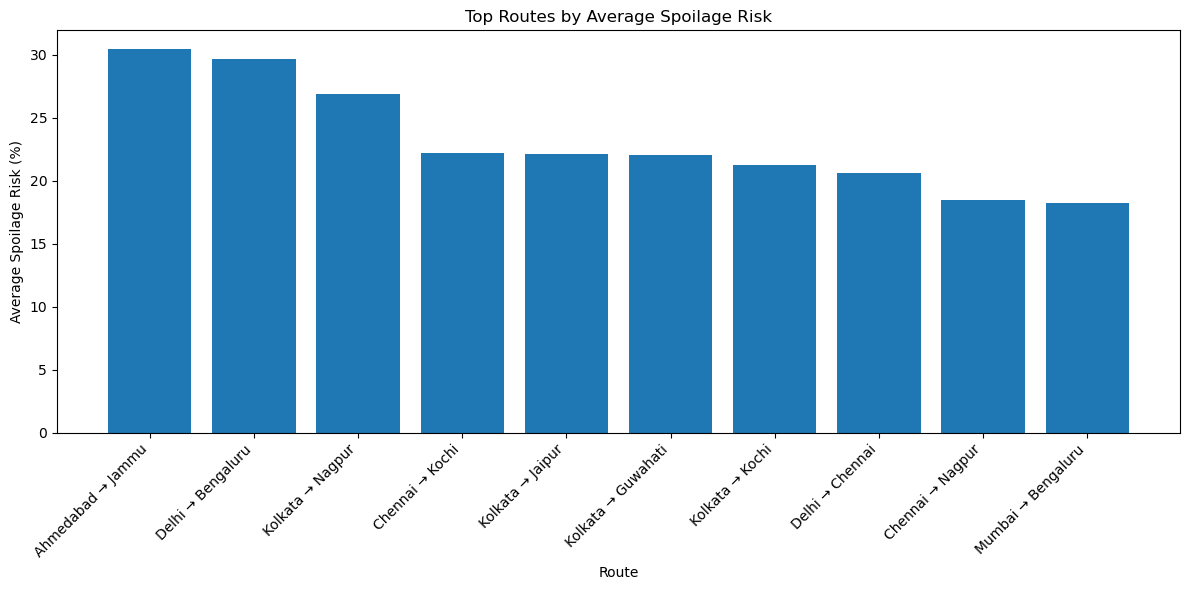

In [13]:
plt.figure(figsize=(12, 6))

top_routes = route_table.head(10)

route_names = (
    top_routes["origin_location"]
    + " → "
    + top_routes["destination_location"]
)

plt.bar(
    route_names,
    top_routes["average_spoilage_risk"]
)

plt.title("Top Routes by Average Spoilage Risk")
plt.xlabel("Route")
plt.ylabel("Average Spoilage Risk (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [14]:
print("Highest average-risk route:")

print(route_table.iloc[0])

Highest average-risk route:
origin_location          Ahmedabad
destination_location         Jammu
average_spoilage_risk         30.4
Name: 0, dtype: object
